# CNN + Data Augmentation Pipeline: Animals Dataset

Nome: Gabriel Filipe da Silva Melo. Matrícula: 125.304-6

This notebook is part of an activity for the Advanced Learning Topics.

In [20]:
import os, sys, glob

_nv_base = os.path.join(sys.prefix, 'lib', 'python3.12', 'site-packages', 'nvidia')
_lib_dirs = glob.glob(os.path.join(_nv_base, '*', 'lib'))
os.environ['LD_LIBRARY_PATH'] = os.pathsep.join(_lib_dirs) + os.pathsep + os.environ.get('LD_LIBRARY_PATH', '')

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import albumentations as A

from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten,
    Dropout, BatchNormalization, SpatialDropout2D,
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import wilcoxon

SEED = 42
np.random.seed(SEED)

# Verify GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✅ GPU detected: {tf.config.experimental.get_device_details(gpus[0])["device_name"]}')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print('⚠️  No GPU detected — running on CPU')

print(f'TensorFlow {tf.__version__}')
print('All imports OK')

✅ GPU detected: NVIDIA GeForce RTX 3060 Ti
TensorFlow 2.21.0
All imports OK


### Load and Explore the Animals Dataset

The dataset is organized as one folder per class inside `../datasets/animals_dataset_jpg_64/`.  
Images are JPEGs with varying aspect ratios, so we **resize every image to 64×64**.

In [21]:
DATASET_DIR = os.path.join("..", "datasets", "animals_dataset_jpg_64")
IMG_SIZE = 64

CLASS_NAMES = sorted(os.listdir(DATASET_DIR))
print(f"Classes found: {CLASS_NAMES}")

images, labels = [], []

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(DATASET_DIR, class_name)
    files = [f for f in os.listdir(class_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    for fname in files:
        img = cv2.imread(os.path.join(class_dir, fname))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img)
        labels.append(class_idx)

images = np.array(images, dtype=np.uint8)
labels = np.array(labels)

print(f"\nTotal images loaded: {len(images)}")
print(f"Image shape: {images[0].shape}")
print(f"Label range: {labels.min()} – {labels.max()}")

Classes found: ['bird', 'cat', 'dog', 'fish', 'hamster', 'rabbit']

Total images loaded: 8430
Image shape: (64, 64, 3)
Label range: 0 – 5


### Class Distribution

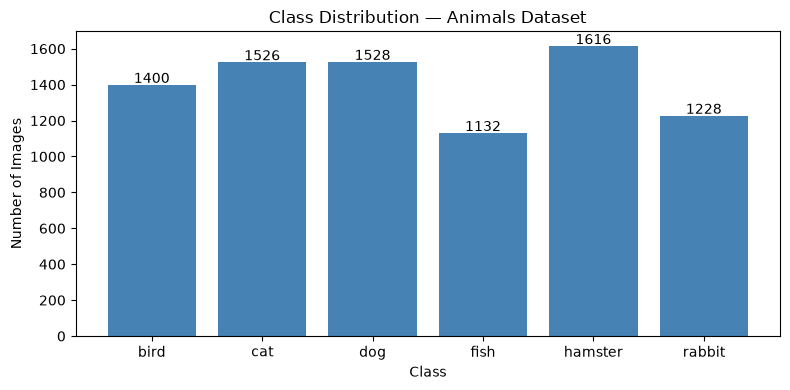


Per-class counts:
        bird: 1400
         cat: 1526
         dog: 1528
        fish: 1132
     hamster: 1616
      rabbit: 1228


In [22]:
unique, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar([CLASS_NAMES[i] for i in unique], counts, color="steelblue")
plt.title("Class Distribution — Animals Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Images")
for i, (u, c) in enumerate(zip(unique, counts)):
    plt.text(i, c + 10, str(c), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

print("\nPer-class counts:")
for u, c in zip(unique, counts):
    print(f"  {CLASS_NAMES[u]:>10}: {c}")

### Images from the Dataset

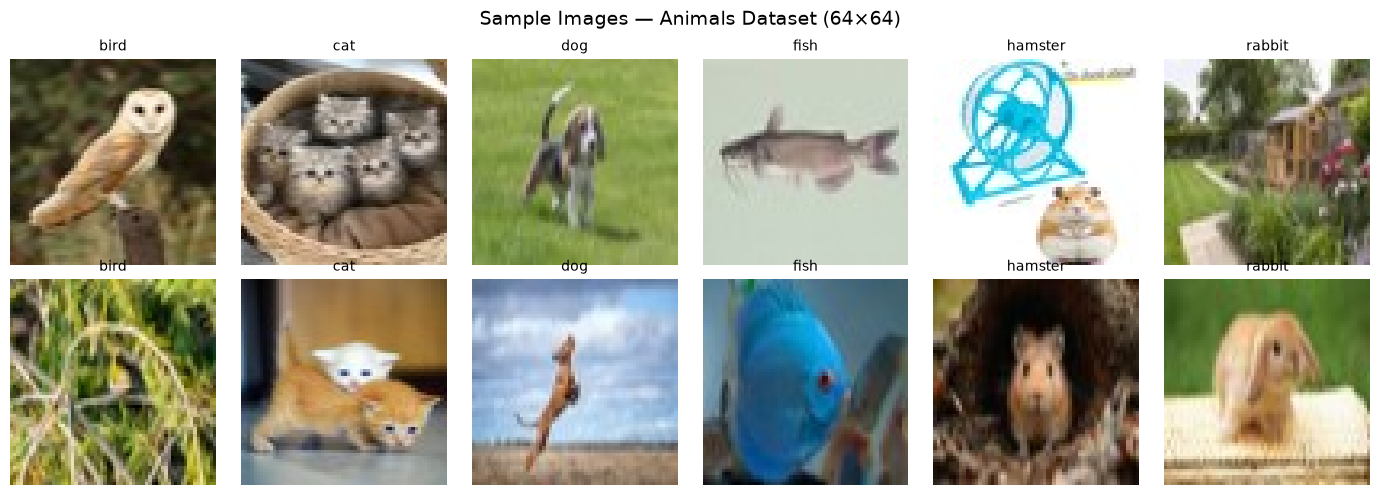

In [23]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))

for col, cls_idx in enumerate(range(len(CLASS_NAMES))):
    cls_mask = np.where(labels == cls_idx)[0]
    samples = np.random.choice(cls_mask, size=2, replace=False)
    for row in range(2):
        ax = axes[row, col]
        ax.imshow(images[samples[row]])
        ax.set_title(CLASS_NAMES[cls_idx], fontsize=10)
        ax.axis("off")

plt.suptitle("Sample Images — Animals Dataset (64×64)", fontsize=14)
plt.tight_layout()
plt.show()

### Split & Normalization

In [24]:
x_train, x_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, stratify=labels, random_state=SEED,
)

NUM_CLASSES = len(CLASS_NAMES)

# Normalize to [0, 1]
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm  = x_test.astype("float32") / 255.0

# One-hot encode
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat  = to_categorical(y_test, NUM_CLASSES)

print(f"Train: {x_train_norm.shape}, Test: {x_test_norm.shape}")
print(f"Labels — Train: {y_train_cat.shape}, Test: {y_test_cat.shape}")

Train: (6744, 64, 64, 3), Test: (1686, 64, 64, 3)
Labels — Train: (6744, 6), Test: (1686, 6)


## Augmentation Pipeline

The animals dataset has **moderate size (~8,400 images)** and **6 classes**, which makes it prone to overfitting with a deep CNN.

* **HorizontalFlip**: Animals can face left or right — this doubles orientation variability
* **ShiftScaleRotate**: Animals may appear at different positions, scales, and slight rotations in real photos
* **RandomBrightnessContrast**: Photos taken under varying lighting conditions
* **HueSaturationValue**: Natural color variation in fur/feathers/scales
* **GaussianBlur**: Simulates slightly out-of-focus photos common in amateur shots
* **CoarseDropout**: Acts like Cutout — forces the model to learn from partial views, reducing reliance on single discriminative patches

In [25]:
augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.1, scale_limit=0.15, rotate_limit=15,
        border_mode=cv2.BORDER_REFLECT_101, p=0.5,
    ),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.CoarseDropout(
        num_holes_range=(1, 3), hole_height_range=(8, 16), hole_width_range=(8, 16),
        fill=0, p=0.3,
    ),
])


def augment_image(image):
    """Apply the Albumentations pipeline to a single uint8 image."""
    return augmentation_pipeline(image=image)["image"]


print("Augmentation pipeline ready.")
print(augmentation_pipeline)

Augmentation pipeline ready.
Compose([
  HorizontalFlip(p=0.5),
  ShiftScaleRotate(p=0.5, shift_limit_x=(-0.1, 0.1), shift_limit_y=(-0.1, 0.1), scale_limit=(-0.15000000000000002, 0.1499999999999999), rotate_limit=(-15.0, 15.0), interpolation=1, border_mode=4, fill=0.0, fill_mask=0.0, rotate_method='largest_box', mask_interpolation=0),
  RandomBrightnessContrast(p=0.4, brightness_by_max=True, brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), ensure_safe_range=False),
  HueSaturationValue(p=0.3, hue_shift_limit=(-10.0, 10.0), sat_shift_limit=(-20.0, 20.0), val_shift_limit=(-15.0, 15.0)),
  GaussianBlur(p=0.2, blur_limit=(3, 5), sigma_limit=(0.5, 3.0)),
  CoarseDropout(p=0.3, fill=0.0, fill_mask=None, hole_height_range=(8, 16), hole_width_range=(8, 16), num_holes_range=(1, 3)),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)


/home/melo/Projects/machine-learning/.venv/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


### Visualizing Augmented Images

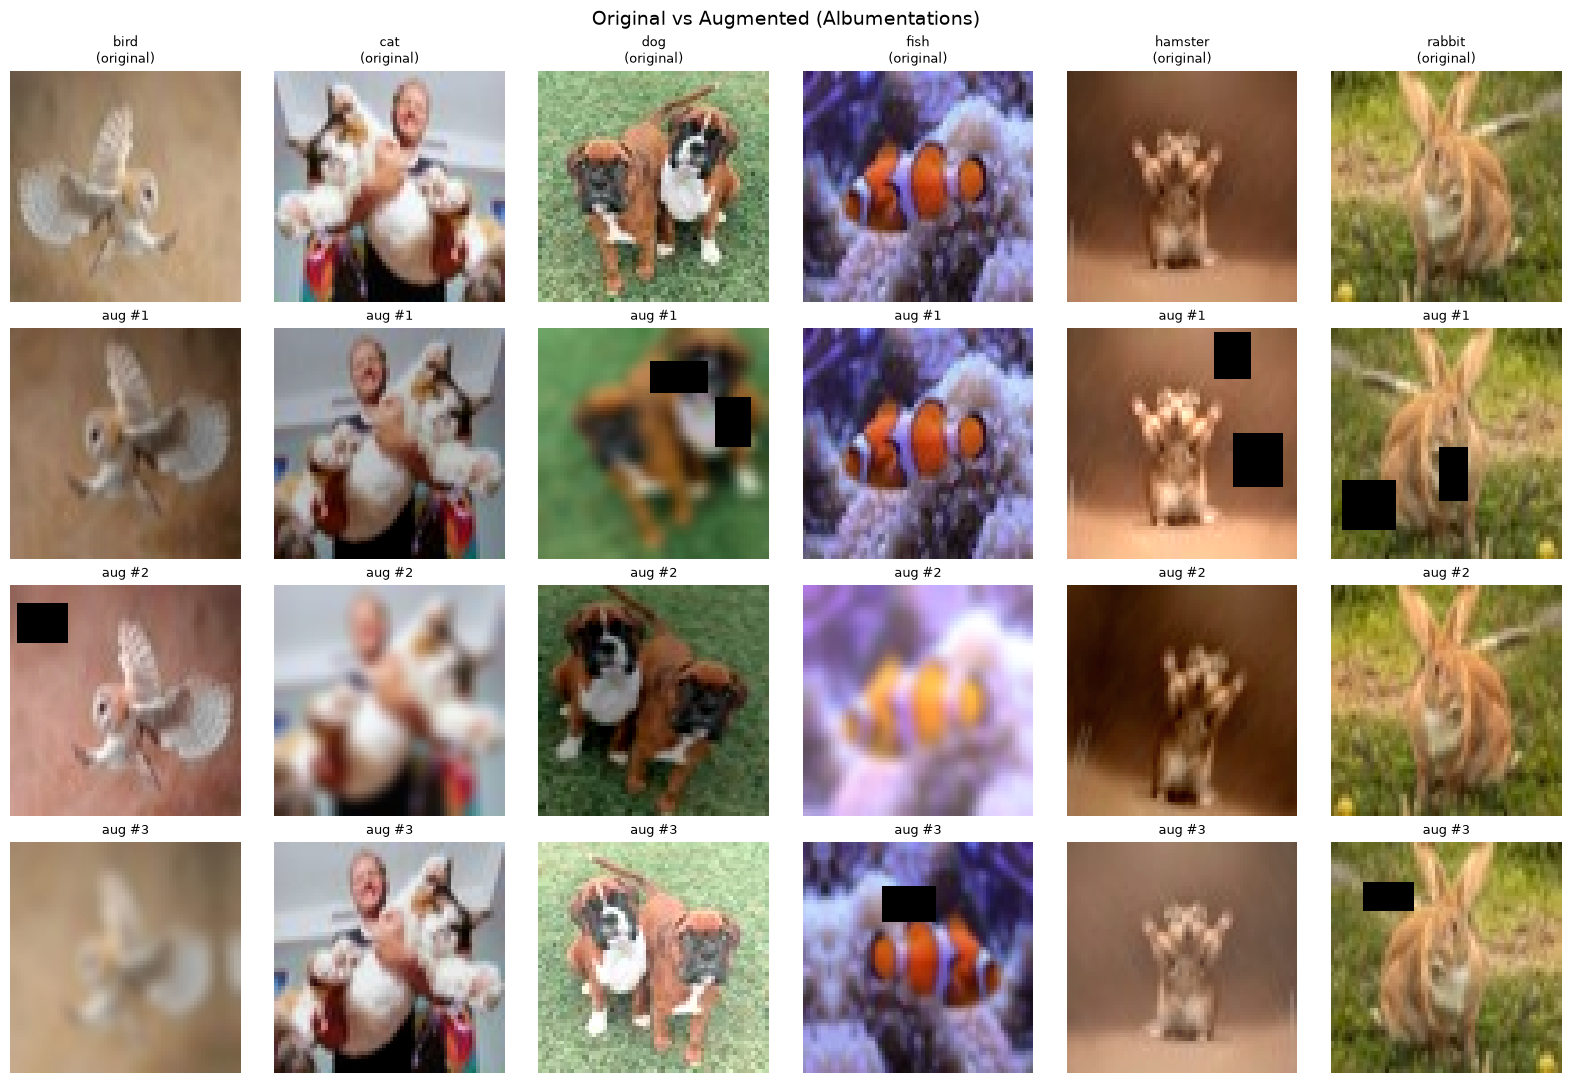

In [26]:
fig, axes = plt.subplots(4, 6, figsize=(16, 11))

# Row 0: originals, Rows 1-3: augmented variants
sample_indices = []
for cls_idx in range(len(CLASS_NAMES)):
    cls_mask = np.where(y_train == cls_idx)[0]
    sample_indices.append(np.random.choice(cls_mask))

for col, idx in enumerate(sample_indices):
    original = x_train[idx]
    axes[0, col].imshow(original)
    axes[0, col].set_title(f"{CLASS_NAMES[y_train[idx]]}\n(original)", fontsize=9)
    axes[0, col].axis("off")

    for row in range(1, 4):
        aug_img = augment_image(original)
        axes[row, col].imshow(aug_img)
        axes[row, col].set_title(f"aug #{row}", fontsize=9)
        axes[row, col].axis("off")

plt.suptitle("Original vs Augmented (Albumentations)", fontsize=14)
plt.tight_layout()
plt.show()

### Build Augmented Training Set

In [27]:
x_train_aug_list = []
y_train_aug_list = []

for img, lbl in zip(x_train, y_train):
    # Keep the original
    x_train_aug_list.append(img)
    y_train_aug_list.append(lbl)
    # Add one augmented copy
    x_train_aug_list.append(augment_image(img))
    y_train_aug_list.append(lbl)

x_train_aug = np.array(x_train_aug_list, dtype=np.uint8)
y_train_aug = np.array(y_train_aug_list)

# Normalize
x_train_aug_norm = x_train_aug.astype("float32") / 255.0
y_train_aug_cat  = to_categorical(y_train_aug, NUM_CLASSES)

print(f"Original training set:  {x_train_norm.shape}")
print(f"Augmented training set: {x_train_aug_norm.shape}")

Original training set:  (6744, 64, 64, 3)
Augmented training set: (13488, 64, 64, 3)


## Regularized CNN Model

In [28]:
def build_regularized_cnn(input_shape=(64, 64, 3), num_classes=6):
    model = Sequential([
        Conv2D(32, (3, 3), activation="relu", padding="same",
               kernel_regularizer=l2(1e-4), input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        SpatialDropout2D(0.25),

        Conv2D(64, (3, 3), activation="relu", padding="same",
               kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        SpatialDropout2D(0.25),

        Conv2D(128, (3, 3), activation="relu", padding="same",
               kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        SpatialDropout2D(0.25),

        Flatten(),
        Dense(256, activation="relu", kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation="softmax"),
    ])
    return model

### Training Without Augmentation (Normal)

In [29]:
EPOCHS = 50
BATCH_SIZE = 64

model_normal = build_regularized_cnn()
model_normal.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_normal = model_normal.fit(
    x_train_norm, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[],
    verbose=1,
)

model_normal.save('model_normal.keras')

del model_normal
import gc; gc.collect()
keras.backend.clear_session()


Epoch 1/50


/home/melo/Projects/machine-learning/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1788746661.674297   42844 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_252043__.74


88/90 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3146 - loss: 2.2287

I0000 00:00:1788746665.347478   42844 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_252043__.74


90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.3151 - loss: 2.2217 - val_accuracy: 0.1522 - val_loss: 3.5504
Epoch 2/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3758 - loss: 1.8045 - val_accuracy: 0.1522 - val_loss: 3.2161
Epoch 3/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4187 - loss: 1.6457 - val_accuracy: 0.1976 - val_loss: 2.7767
Epoch 4/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4557 - loss: 1.5214 - val_accuracy: 0.2628 - val_loss: 1.8877
Epoch 5/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4808 - loss: 1.4544 - val_accuracy: 0.3340 - val_loss: 1.7803
Epoch 6/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5051 - loss: 1.4053 - val_accuracy: 0.4634 - val_loss: 1.4352
Epoch 7/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5370 - loss: 1.3181 - val_accuracy: 0.5375 - val_loss: 1.3225
Epoch 8/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5584 - loss: 1.2733 - val_accuracy: 0.5455 - val_loss: 1.

### Training With Augmentation (Transformed)

In [30]:
model_augmented = build_regularized_cnn()
model_augmented.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_augmented = model_augmented.fit(
    x_train_aug_norm, y_train_aug_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[],
    verbose=1,
)

model_augmented.save('model_augmented.keras')

del model_augmented
import gc; gc.collect()
keras.backend.clear_session()


Epoch 1/50


I0000 00:00:1788746719.888721   42846 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_279538__.74


176/180 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3117 - loss: 2.1403

I0000 00:00:1788746724.362570   42848 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_279538__.74


180/180 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.3138 - loss: 2.1310 - val_accuracy: 0.1907 - val_loss: 2.7449
Epoch 2/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3946 - loss: 1.6773 - val_accuracy: 0.2367 - val_loss: 1.9915
Epoch 3/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4470 - loss: 1.5488 - val_accuracy: 0.4244 - val_loss: 1.5307
Epoch 4/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4706 - loss: 1.4601 - val_accuracy: 0.5163 - val_loss: 1.3455
Epoch 5/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5237 - loss: 1.3643 - val_accuracy: 0.5257 - val_loss: 1.3656
Epoch 6/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5406 - loss: 1.3156 - val_accuracy: 0.5583 - val_loss: 1.2790
Epoch 7/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5607 - loss: 1.2685 - val_accuracy: 0.5618 - val_loss: 1.2825
Epoch 8/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5871 - loss: 1.2298 - val_accuracy: 0.567

### Training Curves Comparison

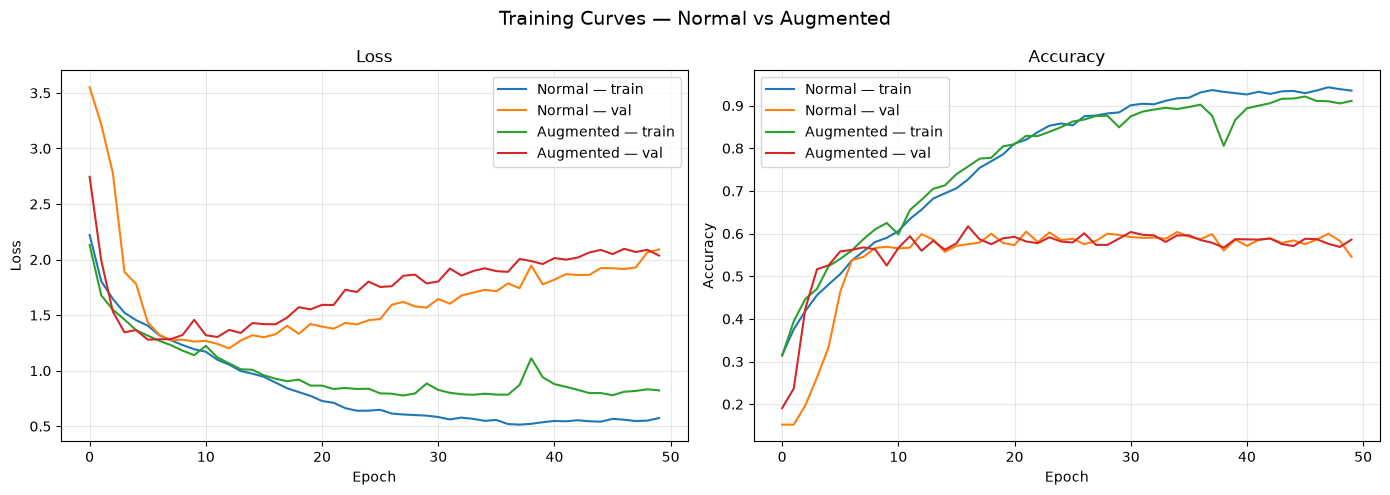

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Loss ----
axes[0].plot(history_normal.history["loss"], label="Normal — train")
axes[0].plot(history_normal.history["val_loss"], label="Normal — val")
axes[0].plot(history_augmented.history["loss"], label="Augmented — train")
axes[0].plot(history_augmented.history["val_loss"], label="Augmented — val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---- Accuracy ----
axes[1].plot(history_normal.history["accuracy"], label="Normal — train")
axes[1].plot(history_normal.history["val_accuracy"], label="Normal — val")
axes[1].plot(history_augmented.history["accuracy"], label="Augmented — train")
axes[1].plot(history_augmented.history["val_accuracy"], label="Augmented — val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Training Curves — Normal vs Augmented", fontsize=14)
plt.tight_layout()
plt.show()

### Evaluation on Test Set

In [32]:
print('Loading models from disk...')
model_normal = keras.models.load_model('model_normal.keras')
model_augmented = keras.models.load_model('model_augmented.keras')

loss_normal, acc_normal     = model_normal.evaluate(x_test_norm, y_test_cat, verbose=0)
loss_aug, acc_aug           = model_augmented.evaluate(x_test_norm, y_test_cat, verbose=0)

print(f"{'Model':<25} {'Test Loss':>10} {'Test Acc':>10}")
print("-" * 47)
print(f"{'Normal (aug)':<25} {loss_aug:>10.4f} {acc_aug:>10.4f}")
print(f"{'Augmented':<25} {loss_normal:>10.4f} {acc_normal:>10.4f}")


Loading models from disk...
Model                      Test Loss   Test Acc
-----------------------------------------------
Normal (aug)                  1.9359     0.6222
Augmented                     1.9818     0.5593


### Classification Reports

In [33]:
y_pred_normal = np.argmax(model_normal.predict(x_test_norm, verbose=0), axis=1)
y_pred_aug    = np.argmax(model_augmented.predict(x_test_norm, verbose=0), axis=1)
y_true        = y_test

print("Classification Report Normal (No Augmentation)")
print("=" * 60)
print(classification_report(y_true, y_pred_normal, target_names=CLASS_NAMES))

print("\nClassification Report With Augmentation")
print("=" * 60)
print(classification_report(y_true, y_pred_aug, target_names=CLASS_NAMES))

Classification Report Normal (No Augmentation)
              precision    recall  f1-score   support

        bird       0.61      0.61      0.61       280
         cat       0.45      0.44      0.44       305
         dog       0.53      0.55      0.54       306
        fish       0.69      0.62      0.65       226
     hamster       0.64      0.60      0.62       323
      rabbit       0.48      0.56      0.52       246

    accuracy                           0.56      1686
   macro avg       0.57      0.56      0.56      1686
weighted avg       0.56      0.56      0.56      1686


Classification Report With Augmentation
              precision    recall  f1-score   support

        bird       0.69      0.65      0.67       280
         cat       0.55      0.53      0.54       305
         dog       0.64      0.61      0.63       306
        fish       0.65      0.71      0.68       226
     hamster       0.61      0.74      0.67       323
      rabbit       0.59      0.48      0.53 

### Confusion Matrices

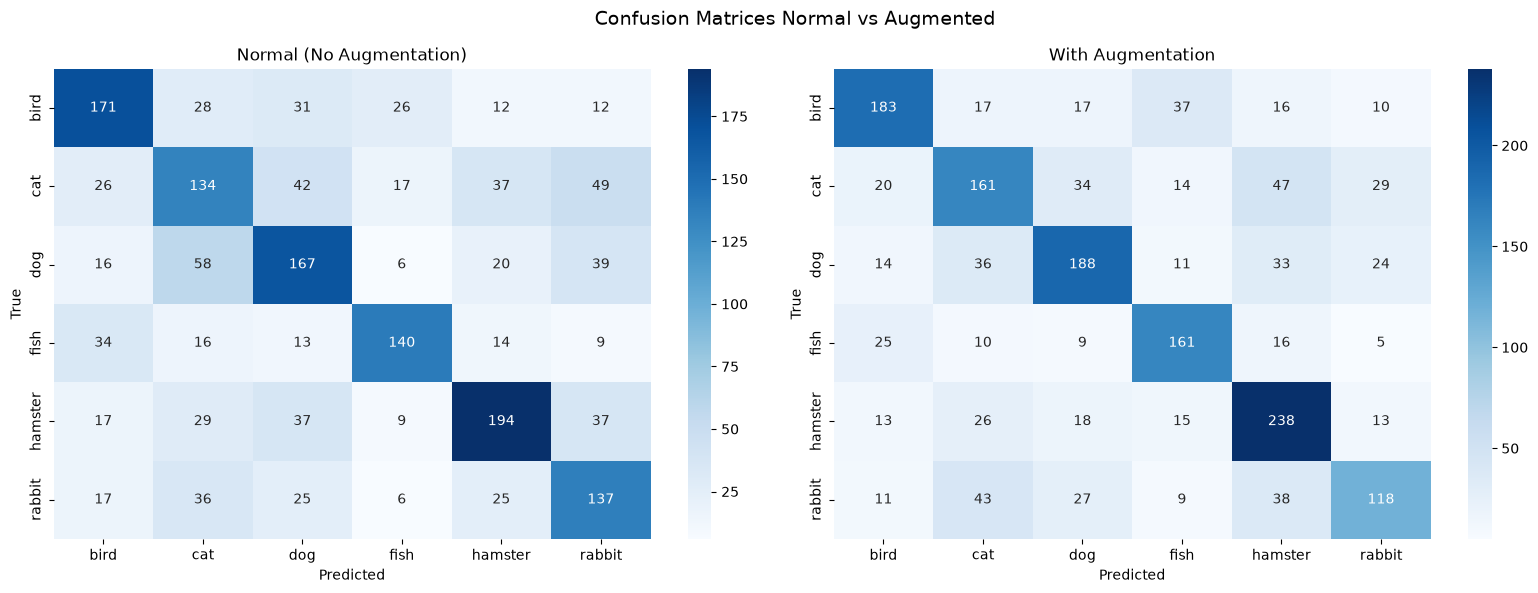

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title in [
    (axes[0], y_pred_normal, "Normal (No Augmentation)"),
    (axes[1], y_pred_aug,    "With Augmentation"),
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Confusion Matrices Normal vs Augmented", fontsize=14)
plt.tight_layout()
plt.show()

In [35]:
# Clean up GPU memory from previous models before starting the heavy Cross-Validation loop
import gc
import tensorflow as tf
from tensorflow import keras

try:
    del model_normal
    del model_augmented
except NameError:
    pass

keras.backend.clear_session()
gc.collect()

print("✅ GPU Memory cleaned up for Cross-Validation.")


✅ GPU Memory cleaned up for Cross-Validation.


### Wilcoxon Signed-Rank Test

To rigorously compare the two approaches, we use **Stratified K-Fold cross-validation** (5 folds) to collect paired accuracy scores, then apply the **Wilcoxon signed-rank test**.

In [36]:
import gc
N_FOLDS = 5
FOLD_EPOCHS = 30

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

scores_normal = []
scores_augmented = []

# Use the raw (uint8) images so we can augment properly
all_images = images
all_labels = labels

for fold, (train_idx, val_idx) in enumerate(skf.split(all_images, all_labels)):
    print(f"\n{'='*60}")
    print(f"Fold {fold + 1}/{N_FOLDS}")
    print(f"{'='*60}")

    X_tr_raw, X_val_raw = all_images[train_idx], all_images[val_idx]
    y_tr, y_val         = all_labels[train_idx], all_labels[val_idx]

    # Normalize
    X_tr  = X_tr_raw.astype("float32") / 255.0
    X_val = X_val_raw.astype("float32") / 255.0
    y_tr_cat  = to_categorical(y_tr, NUM_CLASSES)
    y_val_cat = to_categorical(y_val, NUM_CLASSES)

    # ---- Normal ----
    m_normal = build_regularized_cnn()
    m_normal.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    m_normal.fit(X_tr, y_tr_cat, epochs=FOLD_EPOCHS, batch_size=BATCH_SIZE,
                 validation_data=(X_val, y_val_cat), verbose=0,
                 callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)])
    _, acc_n = m_normal.evaluate(X_val, y_val_cat, verbose=0)
    scores_normal.append(acc_n)
    print(f"  Normal accuracy:    {acc_n:.4f}")

    # ---- Augmented ----
    # Build augmented training set for this fold
    X_aug_list, y_aug_list = [], []
    for img, lbl in zip(X_tr_raw, y_tr):
        X_aug_list.append(img)
        y_aug_list.append(lbl)
        X_aug_list.append(augment_image(img))
        y_aug_list.append(lbl)

    X_tr_aug = np.array(X_aug_list, dtype="float32") / 255.0
    y_tr_aug_cat = to_categorical(np.array(y_aug_list), NUM_CLASSES)

    m_aug = build_regularized_cnn()
    m_aug.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    m_aug.fit(X_tr_aug, y_tr_aug_cat, epochs=FOLD_EPOCHS, batch_size=BATCH_SIZE,
              validation_data=(X_val, y_val_cat), verbose=0,
              callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)])
    _, acc_a = m_aug.evaluate(X_val, y_val_cat, verbose=0)
    scores_augmented.append(acc_a)
    print(f"  Augmented accuracy: {acc_a:.4f}")

    # Clean up to free memory
    del m_normal, m_aug, X_tr, X_val, X_tr_aug
    keras.backend.clear_session()
    gc.collect()

print(f"\n{'='*60}")



Fold 1/5


/home/melo/Projects/machine-learning/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1788746830.012627   42845 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_332728__.74
I0000 00:00:1788746833.668590   42848 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_332728__.74


  Normal accuracy:    0.5712


I0000 00:00:1788746859.108385   42846 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_347502__.74
I0000 00:00:1788746863.800893   42848 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_347502__.74


  Augmented accuracy: 0.5896

Fold 2/5


...

  Augmented accuracy: 0.5979

Fold 5/5


I0000 00:00:1788747106.727037   42844 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_468755__.74
I0000 00:00:1788747110.515586   42844 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_468755__.74


  Normal accuracy:    0.6103


I0000 00:00:1788747136.791871   42845 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_484036__.74
I0000 00:00:1788747141.530958   42844 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_484036__.74


  Augmented accuracy: 0.6192



In [37]:
scores_normal = np.array(scores_normal)
scores_augmented = np.array(scores_augmented)

print(f"Normal accuracies:    {scores_normal}")
print(f"Augmented accuracies: {scores_augmented}")
print(f"\nNormal mean:    {scores_normal.mean():.4f} ± {scores_normal.std():.4f}")
print(f"Augmented mean: {scores_augmented.mean():.4f} ± {scores_augmented.std():.4f}")

# Wilcoxon signed-rank test
stat, p_value = wilcoxon(scores_normal, scores_augmented)

print(f"\n--- Wilcoxon Signed-Rank Test ---")
print(f"Statistic: {stat:.4f}")
print(f"P-value:   {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\n→ p < {alpha}: REJECT H₀ - The difference IS statistically significant.")
else:
    print(f"\n→ p ≥ {alpha}: FAIL TO REJECT H₀ - No significant difference detected.")
    print("  (Note: with only 5 folds, the test has limited statistical power.)")

Normal accuracies:    [0.57117438 0.61150652 0.599051   0.59193355 0.61032027]
Augmented accuracies: [0.5895611  0.59252667 0.60794783 0.59786475 0.6192171 ]

Normal mean:    0.5968 ± 0.0147
Augmented mean: 0.6014 ± 0.0109

--- Wilcoxon Signed-Rank Test ---
Statistic: 5.0000
P-value:   0.6250

→ p ≥ 0.05: FAIL TO REJECT H₀ - No significant difference detected.
  (Note: with only 5 folds, the test has limited statistical power.)


### Visualizing Predictions

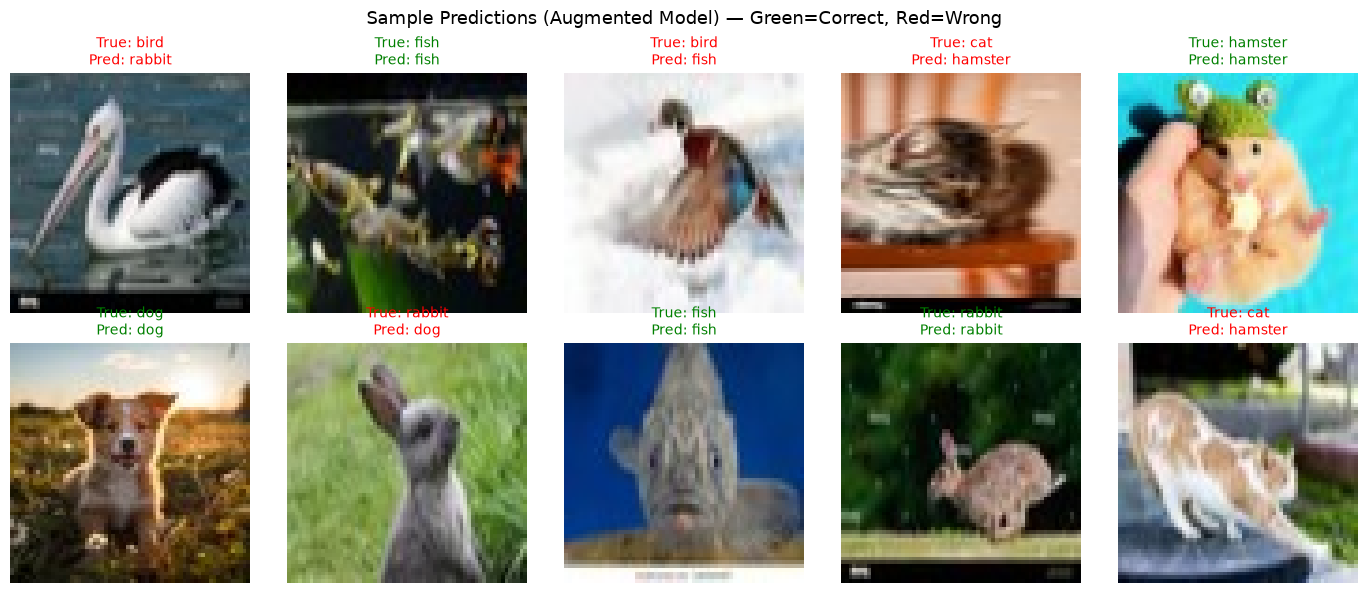

In [38]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

indices = np.random.choice(len(x_test_norm), 10, replace=False)

for i, ax in enumerate(axes.flat):
    idx = indices[i]
    ax.imshow(x_test_norm[idx])
    true_label = CLASS_NAMES[y_true[idx]]
    pred_label = CLASS_NAMES[y_pred_aug[idx]]
    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
    ax.axis("off")

plt.suptitle("Sample Predictions (Augmented Model) — Green=Correct, Red=Wrong", fontsize=13)
plt.tight_layout()
plt.show()